In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import torch

In [2]:
data_dir = Path("../data/")
model_dir = Path("../models/")

recyclable_dir = data_dir / "recyclable"
non_recyclable_dir = data_dir / "non_recyclable"

cardboard_dir = recyclable_dir / "cardboard"
glass_dir = recyclable_dir / "glass"
metal_dir = recyclable_dir / "metal"
paper_dir = recyclable_dir / "paper"
plastic_dir = recyclable_dir / "plastic"
trash_dir = non_recyclable_dir / "trash"

In [3]:
def walk_through_directory(directory):
    for root, dirs, files in os.walk(directory):
        print(f"There are {len(dirs)} directories and {len(files)} files in '{root}'")

In [4]:
walk_through_directory(recyclable_dir)

There are 5 directories and 0 files in '..\data\recyclable'
There are 0 directories and 404 files in '..\data\recyclable\cardboard'
There are 0 directories and 502 files in '..\data\recyclable\glass'
There are 0 directories and 411 files in '..\data\recyclable\metal'
There are 0 directories and 595 files in '..\data\recyclable\paper'
There are 0 directories and 483 files in '..\data\recyclable\plastic'


In [5]:
walk_through_directory(non_recyclable_dir)

There are 1 directories and 0 files in '..\data\non_recyclable'
There are 0 directories and 137 files in '..\data\non_recyclable\trash'


In [9]:
# Get a random sample of images and labels for checking

import random
from PIL import Image

dirs = [cardboard_dir, glass_dir, metal_dir, paper_dir, plastic_dir, trash_dir]

selected_dir = random.choice(dirs)
image_paths = list(selected_dir.glob("*.jpg")) + list(selected_dir.glob("*.png")) + list(selected_dir.glob("*.jpeg"))

if not image_paths:
    print(f"No images found in {selected_dir}")
else:
    image_path = random.choice(image_paths)
    label = image_path.parent.name

    print(f"Selected image path: {image_path}")

    img = Image.open(image_path)

    print(f"Image mode: {img.mode}")
    print(f"Image size: {img.size}")
    print(f"Image height: {img.height}")
    print(f"Image width: {img.width}")
    print(f"Image label: {label}")
    print(f"Image format: {img.format}")

    img.show()

Selected image path: ..\data\recyclable\glass\glass422.jpg
Image mode: RGB
Image size: (4032, 3024)
Image height: 3024
Image width: 4032
Image label: glass
Image format: JPEG


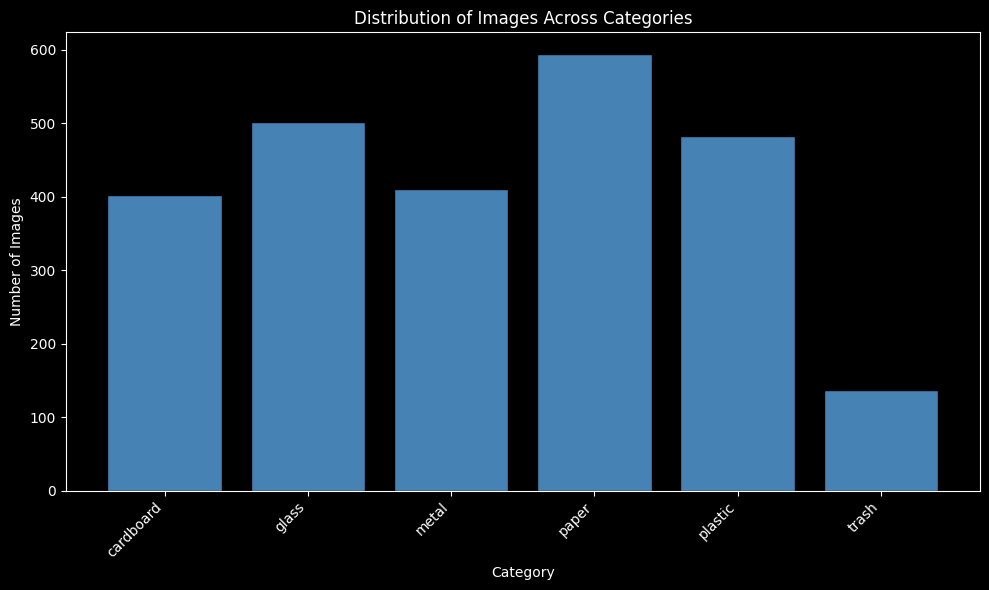


File counts per directory:
cardboard: 403 images
glass: 501 images
metal: 410 images
paper: 594 images
plastic: 482 images
trash: 137 images


In [11]:
# Distribution of number of files in each directory

dir_names = []
file_counts = []

for directory in dirs:
    images = list(directory.glob("*.jpg")) + list(directory.glob("*.png")) + list(directory.glob("*.jpeg"))
    dir_names.append(directory.name)
    file_counts.append(len(images))

plt.figure(figsize=(10, 6))
plt.bar(dir_names, file_counts, color='steelblue', edgecolor='black')
plt.xlabel('Category')
plt.ylabel('Number of Images')
plt.title('Distribution of Images Across Categories')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\nFile counts per directory:")
for name, count in zip(dir_names, file_counts):
    print(f"{name}: {count} images")

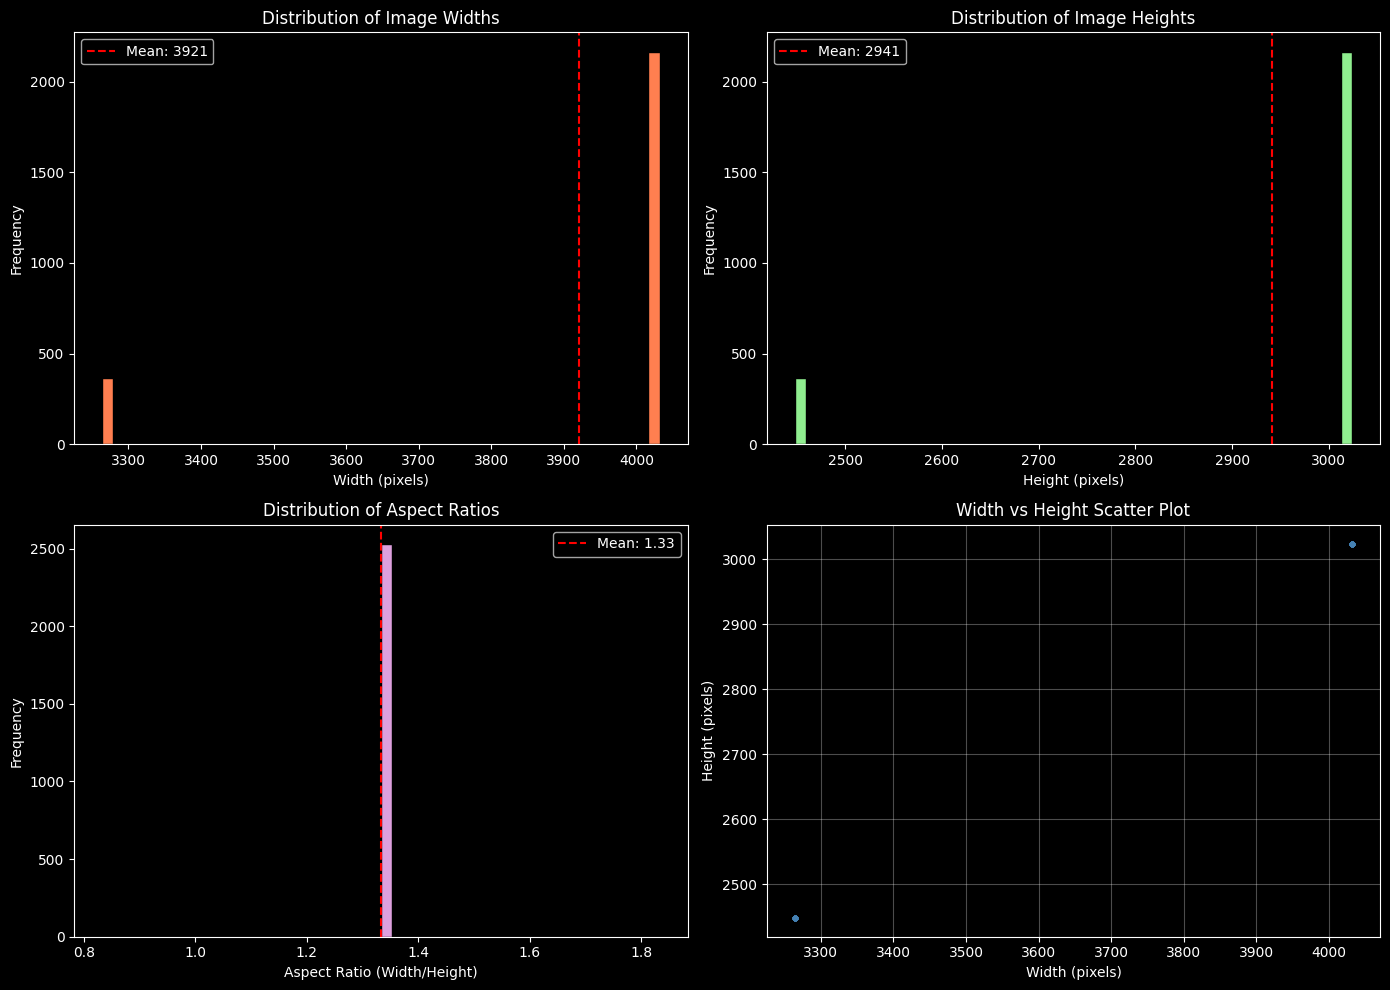


Image size statistics:
Width - Min: 3264, Max: 4032, Mean: 3921.37, Std: 269.67
Height - Min: 2448, Max: 3024, Mean: 2941.03, Std: 202.25
Aspect Ratio - Min: 1.33, Max: 1.33, Mean: 1.33
Total images analyzed: 2527


In [14]:
# Distribution of images across image sizes

widths = []
heights = []
aspect_ratios = []

for directory in dirs:
    images = list(directory.glob("*.jpg")) + list(directory.glob("*.png")) + list(directory.glob("*.jpeg"))
    
    for img_path in images:
        try:
            with Image.open(img_path) as img:
                width, height = img.size
                widths.append(width)
                heights.append(height)
                aspect_ratios.append(width / height)
        except Exception as e:
            print(f"Error reading {img_path}: {e}")

# Plot image size distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Width distribution
axes[0, 0].hist(widths, bins=50, color='coral', edgecolor='black')
axes[0, 0].set_xlabel('Width (pixels)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].set_title('Distribution of Image Widths')
axes[0, 0].axvline(np.mean(widths), color='red', linestyle='--', label=f'Mean: {np.mean(widths):.0f}')
axes[0, 0].legend()

# Height distribution
axes[0, 1].hist(heights, bins=50, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Height (pixels)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Distribution of Image Heights')
axes[0, 1].axvline(np.mean(heights), color='red', linestyle='--', label=f'Mean: {np.mean(heights):.0f}')
axes[0, 1].legend()

# Aspect ratio distribution
axes[1, 0].hist(aspect_ratios, bins=50, color='plum', edgecolor='black')
axes[1, 0].set_xlabel('Aspect Ratio (Width/Height)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Distribution of Aspect Ratios')
axes[1, 0].axvline(np.mean(aspect_ratios), color='red', linestyle='--', label=f'Mean: {np.mean(aspect_ratios):.2f}')
axes[1, 0].legend()

# Scatter plot of width vs height
axes[1, 1].scatter(widths, heights, alpha=0.5, s=10, color='steelblue')
axes[1, 1].set_xlabel('Width (pixels)')
axes[1, 1].set_ylabel('Height (pixels)')
axes[1, 1].set_title('Width vs Height Scatter Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nImage size statistics:")
print(f"Width - Min: {min(widths)}, Max: {max(widths)}, Mean: {np.mean(widths):.2f}, Std: {np.std(widths):.2f}")
print(f"Height - Min: {min(heights)}, Max: {max(heights)}, Mean: {np.mean(heights):.2f}, Std: {np.std(heights):.2f}")
print(f"Aspect Ratio - Min: {min(aspect_ratios):.2f}, Max: {max(aspect_ratios):.2f}, Mean: {np.mean(aspect_ratios):.2f}")
print(f"Total images analyzed: {len(widths)}")

In [18]:
from torchvision import transforms, datasets

dataset = datasets.ImageFolder(
    root=data_dir)

dataset.classes

['non_recyclable', 'recyclable']

In [19]:
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, random_split

def get_dataloaders(data_dir, batch_size=32, train_split=0.8):
    transfrom = transforms.Compose([
        transforms.Resize((224,224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    dataset = datasets.ImageFolder(root=data_dir, transform=transfrom)

    train_size = int(train_split * len(dataset))
    val_size = len(dataset) - train_size
    train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    
    class_names = dataset.classes
    return train_loader, val_loader, class_names


In [20]:
! pip freeze | grep torchvision

'grep' is not recognized as an internal or external command,
operable program or batch file.
